In [33]:
import os
import json
import random
import shutil
import subprocess
from pathlib import Path

import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

# Google Drive dataset location
GENIMAGE_ROOT = Path("/content/drive/MyDrive/genimage")

# Local Colab working directory
WORK_DIR = Path("/content/genimage_sample")

# Create working directory
WORK_DIR.mkdir(parents=True, exist_ok=True)

print("GenImage root:", GENIMAGE_ROOT)
print("Working directory:", WORK_DIR)

GenImage root: /content/drive/MyDrive/genimage
Working directory: /content/genimage_sample


In [34]:
dataset_sizes = {
    "ADM": 36.17,
    "BigGAN": 22.57,
    "Midjourney": 211.85,
    "VQDM": 35.58,
    "glide": 30.05,
    "stable_diffusion_v_1_4": 89.79,
    "stable_diffusion_v_1_5": 94.76,
    "wukong": 90.56
}

size_df = pd.DataFrame(
    list(dataset_sizes.items()),
    columns=["Dataset", "Size_GB"]
)

size_df = size_df.sort_values("Size_GB", ascending=False)

display(size_df)

print(f"\nApproximate total: {size_df['Size_GB'].sum():.2f} GB")

,Dataset,Size_GB
2,Midjourney,211.85
6,stable_diffusion_v_1_5,94.76
7,wukong,90.56
5,stable_diffusion_v_1_4,89.79
0,ADM,36.17
3,VQDM,35.58
4,glide,30.05
1,BigGAN,22.57



Approximate total: 611.33 GB


In [35]:
!apt-get -qq update
!apt-get -qq install p7zip-full

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


In [43]:
import subprocess
import random
from pathlib import Path

# BigGAN archive
biggan_archive = (
    GENIMAGE_ROOT
    / "BigGAN"
    / "imagenet_ai_0419_biggan.zip"
)

print("Reading archive file list...")

result = subprocess.run(
    ["7z", "l", "-slt", str(biggan_archive)],
    capture_output=True,
    text=True
)

if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("Could not read BigGAN archive")

# Extract actual archive paths
archive_paths = []

for line in result.stdout.splitlines():
    if line.startswith("Path = "):
        p = line[len("Path = "):].strip()

        if p != str(biggan_archive):
            archive_paths.append(p)

print("Total archive entries:", len(archive_paths))

# Show some actual paths
for p in archive_paths[:10]:
    print(p)

Reading archive file list...
Total archive entries: 336007
imagenet_ai_0419_biggan
imagenet_ai_0419_biggan/train
imagenet_ai_0419_biggan/train/ai
imagenet_ai_0419_biggan/train/ai/000_biggan_00000.png
imagenet_ai_0419_biggan/train/ai/000_biggan_00001.png
imagenet_ai_0419_biggan/train/ai/000_biggan_00002.png
imagenet_ai_0419_biggan/train/ai/000_biggan_00004.png
imagenet_ai_0419_biggan/train/ai/000_biggan_00005.png
imagenet_ai_0419_biggan/train/ai/000_biggan_00006.png
imagenet_ai_0419_biggan/train/ai/000_biggan_00007.png


In [44]:
random.seed(42)

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".webp"
)

ai_files = [
    p for p in archive_paths
    if "/ai/" in p.lower()
    and p.lower().endswith(IMAGE_EXTENSIONS)
]

print("AI images found:", len(ai_files))

SAMPLE_SIZE = 500

selected_ai = random.sample(
    ai_files,
    min(SAMPLE_SIZE, len(ai_files))
)

print("Selected:", len(selected_ai))

print("\nFirst 10 selected files:")
for p in selected_ai[:10]:
    print(p)

AI images found: 168000
Selected: 500

First 10 selected files:
imagenet_ai_0419_biggan/val/ai/936_biggan_00143.png
imagenet_ai_0419_biggan/train/ai/180_biggan_00032.png
imagenet_ai_0419_biggan/train/ai/040_biggan_00094.png
imagenet_ai_0419_biggan/train/ai/445_biggan_00008.png
imagenet_ai_0419_biggan/train/ai/396_biggan_00056.png
imagenet_ai_0419_biggan/train/ai/361_biggan_00043.png
imagenet_ai_0419_biggan/train/ai/225_biggan_00159.png
imagenet_ai_0419_biggan/train/ai/165_biggan_00170.png
imagenet_ai_0419_biggan/train/ai/882_biggan_00098.png
imagenet_ai_0419_biggan/train/ai/140_biggan_00136.png


In [45]:
biggan_work = WORK_DIR / "biggan"
biggan_work.mkdir(parents=True, exist_ok=True)

list_file = biggan_work / "extract_list.txt"

with open(list_file, "w") as f:
    for p in selected_ai:
        f.write(p + "\n")

print("Extraction list created:")
print(list_file)

print("\nNumber of entries:", len(selected_ai))

Extraction list created:
/content/genimage_sample/biggan/extract_list.txt

Number of entries: 500


In [46]:
extract_dir = biggan_work / "raw"

if extract_dir.exists():
    shutil.rmtree(extract_dir)

extract_dir.mkdir(parents=True, exist_ok=True)

cmd = [
    "7z",
    "x",
    str(biggan_archive),
    f"-o{extract_dir}",
    f"@{list_file}",
    "-y"
]

print("Starting extraction of 500 images...")

result = subprocess.run(
    cmd,
    capture_output=True,
    text=True
)

print(result.stdout[-4000:])

if result.returncode != 0:
    print("\nERROR:")
    print(result.stderr)
else:
    print("\nExtraction command completed.")

Starting extraction of 500 images...

7-Zip 23.01 (x64) : Copyright (c) 1999-2023 Igor Pavlov : 2023-06-20
 64-bit locale=en_US.UTF-8 Threads:2 OPEN_MAX:1048576

Scanning the drive for archives:
1 file, 1687358196 bytes (1610 MiB)

Extracting archive: /content/drive/MyDrive/genimage/BigGAN/imagenet_ai_0419_biggan.zip
--
Path = /content/drive/MyDrive/genimage/BigGAN/imagenet_ai_0419_biggan.zip
Type = zip
Physical Size = 1687358196
Embedded Stub Size = 4
64-bit = +
Characteristics = Zip64
Total Physical Size = 24235936500
Multivolume = +
Volume Index = 7
Volumes = 8

Everything is Ok

Files: 500
Size:       14756393
Compressed: 24235936500


Extraction command completed.


In [49]:
from PIL import Image

def check_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True, None

    except Exception as e:
        return False, str(e)


results = []

for i, path in enumerate(biggan_images):

    valid, error = check_image(path)

    results.append({
        "path": str(path),
        "valid": valid,
        "error": error
    })

    if (i + 1) % 100 == 0:
        print(f"Checked {i + 1}/{len(biggan_images)} images")

quality_df = pd.DataFrame(results)

print("\n===== IMAGE VALIDITY =====")
print("Total:", len(quality_df))
print("Valid:", quality_df["valid"].sum())
print("Corrupted:", (~quality_df["valid"]).sum())

Checked 100/500 images
Checked 200/500 images
Checked 300/500 images
Checked 400/500 images
Checked 500/500 images

===== IMAGE VALIDITY =====
Total: 500
Valid: 500
Corrupted: 0


In [50]:
def get_image_info(path):

    try:
        with Image.open(path) as img:

            return {
                "path": str(path),
                "width": img.width,
                "height": img.height,
                "format": img.format,
                "mode": img.mode,
                "file_size_MB": os.path.getsize(path) / (1024 ** 2),
                "valid": True
            }

    except Exception as e:

        return {
            "path": str(path),
            "width": None,
            "height": None,
            "format": None,
            "mode": None,
            "file_size_MB": None,
            "valid": False
        }


image_df = pd.DataFrame(
    [get_image_info(p) for p in biggan_images]
)

display(image_df.head())

,path,width,height,format,mode,file_size_MB,valid
0,/content/genimage_sample/biggan/raw/imagenet_a...,128,128,PNG,RGB,0.028615,True
1,/content/genimage_sample/biggan/raw/imagenet_a...,128,128,PNG,RGB,0.032545,True
2,/content/genimage_sample/biggan/raw/imagenet_a...,128,128,PNG,RGB,0.026462,True
3,/content/genimage_sample/biggan/raw/imagenet_a...,128,128,PNG,RGB,0.038216,True
4,/content/genimage_sample/biggan/raw/imagenet_a...,128,128,PNG,RGB,0.017509,True


In [51]:
print("===== DATASET SUMMARY =====")

print("\nTotal images:")
print(len(image_df))

print("\nImage formats:")
display(image_df["format"].value_counts())

print("\nColor modes:")
display(image_df["mode"].value_counts())

print("\nMost common resolutions:")
display(
    image_df
    .groupby(["width", "height"])
    .size()
    .sort_values(ascending=False)
    .head(20)
)

print("\nFile size statistics:")
display(
    image_df["file_size_MB"].describe()
)

===== DATASET SUMMARY =====

Total images:
500

Image formats:


,count
format,
PNG,500



Color modes:


,count
mode,
RGB,500



Most common resolutions:


,,0
width,height,
128,128,500



File size statistics:


,file_size_MB
count,500.000000
mean,0.028146
std,0.005656
min,0.007405
25%,0.024676
50%,0.028390
75%,0.032062
max,0.041184


In [52]:
print("Width statistics:")
display(image_df["width"].describe())

print("\nHeight statistics:")
display(image_df["height"].describe())

Width statistics:


,width
count,500.0
mean,128.0
std,0.0
min,128.0
25%,128.0
50%,128.0
75%,128.0
max,128.0



Height statistics:


,height
count,500.0
mean,128.0
std,0.0
min,128.0
25%,128.0
50%,128.0
75%,128.0
max,128.0


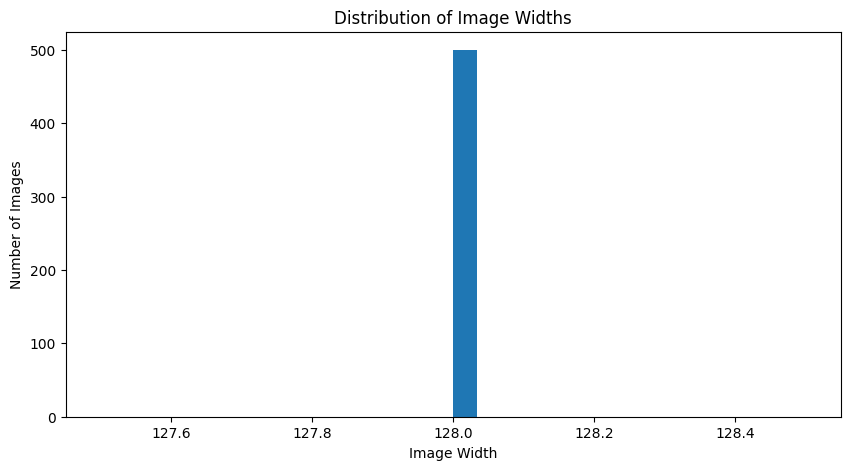

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    image_df["width"].dropna(),
    bins=30
)

plt.xlabel("Image Width")
plt.ylabel("Number of Images")
plt.title("Distribution of Image Widths")

plt.show()

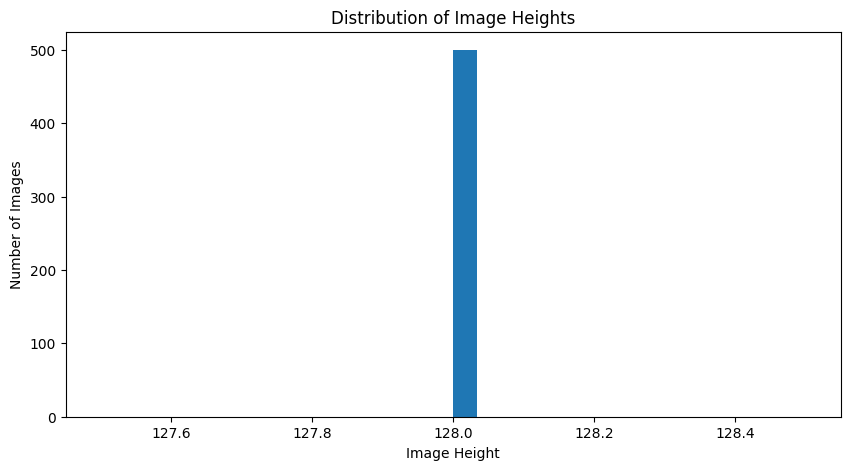

In [54]:
plt.figure(figsize=(10, 5))

plt.hist(
    image_df["height"].dropna(),
    bins=30
)

plt.xlabel("Image Height")
plt.ylabel("Number of Images")
plt.title("Distribution of Image Heights")

plt.show()

In [55]:
MIN_WIDTH = 100
MIN_HEIGHT = 100

small_images = image_df[
    (image_df["width"] < MIN_WIDTH) |
    (image_df["height"] < MIN_HEIGHT)
]

print("Images smaller than threshold:", len(small_images))

display(small_images.head(20))

Images smaller than threshold: 0


,path,width,height,format,mode,file_size_MB,valid


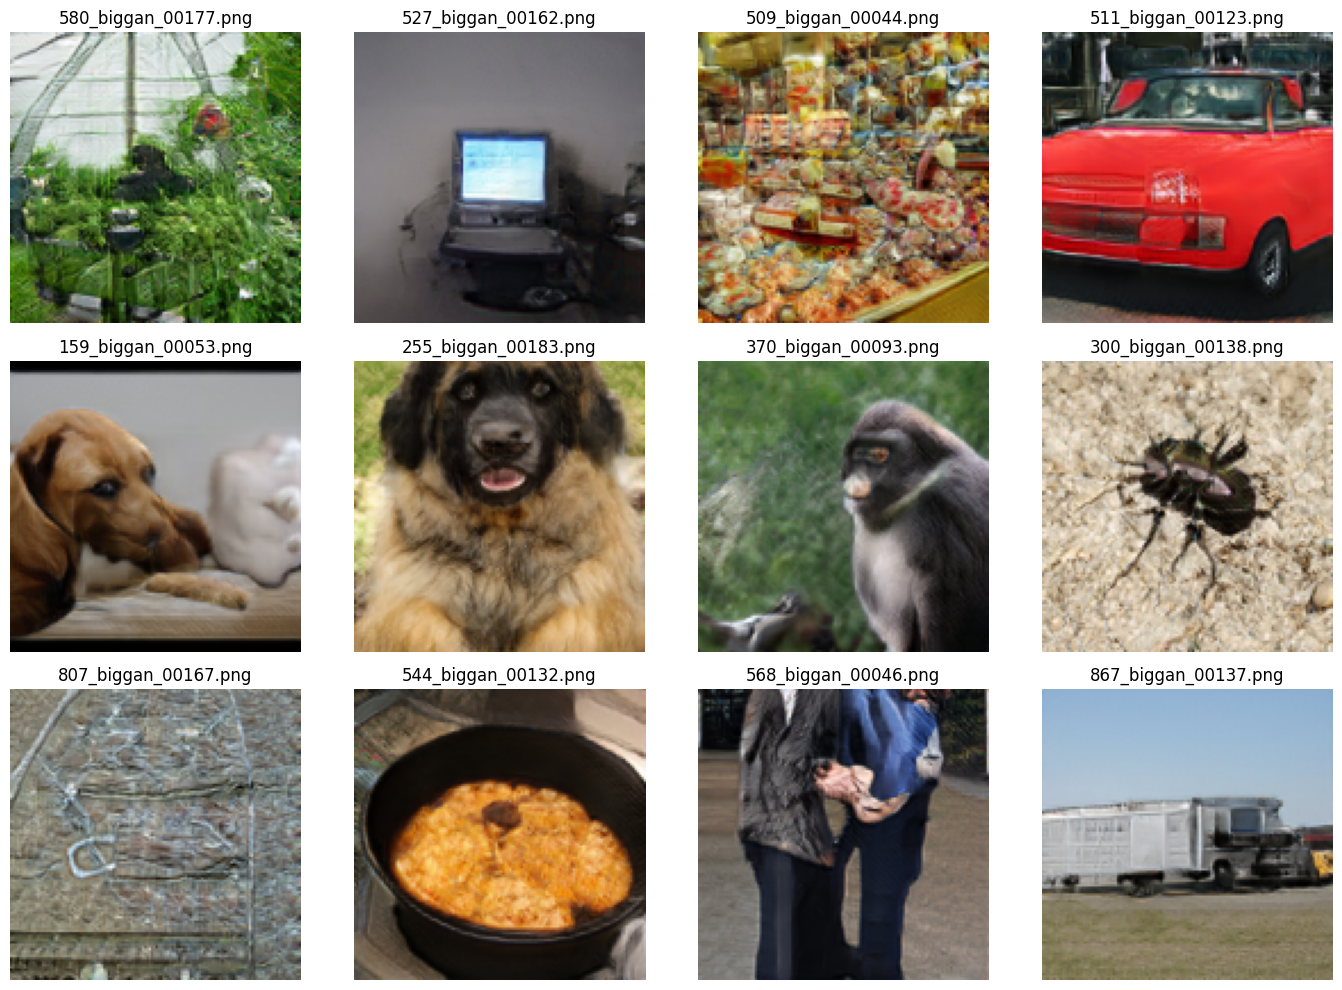

In [56]:
import random

valid_images = [
    Path(p)
    for p in image_df[
        image_df["valid"] == True
    ]["path"]
]

sample_images = random.sample(
    valid_images,
    min(12, len(valid_images))
)

fig, axes = plt.subplots(
    3, 4,
    figsize=(14, 10)
)

for ax, path in zip(axes.flat, sample_images):

    img = Image.open(path).convert("RGB")

    ax.imshow(img)
    ax.set_title(path.name[:25])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [57]:
import hashlib

def md5_hash(path):

    h = hashlib.md5()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            h.update(chunk)

    return h.hexdigest()


hash_records = []

for path in valid_images:

    hash_records.append({
        "path": str(path),
        "md5": md5_hash(path)
    })


hash_df = pd.DataFrame(hash_records)

hash_counts = hash_df["md5"].value_counts()

duplicate_groups = hash_counts[
    hash_counts > 1
]

print("Unique images:", hash_df["md5"].nunique())
print("Total images:", len(hash_df))
print("Duplicate groups:", len(duplicate_groups))
print(
    "Files involved in duplicate groups:",
    duplicate_groups.sum()
)

Unique images: 500
Total images: 500
Duplicate groups: 0
Files involved in duplicate groups: 0


In [58]:
mode_counts = image_df["mode"].value_counts()

print("Color mode distribution:")
display(mode_counts)

Color mode distribution:


,count
mode,
RGB,500


In [59]:
def image_mean_std(path):

    try:
        with Image.open(path).convert("RGB") as img:

            arr = np.asarray(img)

            return {
                "path": str(path),
                "mean": arr.mean(),
                "std": arr.std()
            }

    except:
        return {
            "path": str(path),
            "mean": np.nan,
            "std": np.nan
        }


pixel_stats = pd.DataFrame(
    [image_mean_std(p) for p in valid_images]
)

display(pixel_stats.describe())

,mean,std
count,500.000000,500.000000
mean,118.817425,53.494404
std,39.351189,15.646631
min,1.753886,7.632171
25%,94.386637,42.881930
50%,115.779917,51.744685
75%,141.622426,62.409920
max,241.696167,112.485737


In [60]:
uniform_images = pixel_stats[
    pixel_stats["std"] < 5
]

print(
    "Potentially uniform/blank images:",
    len(uniform_images)
)

display(uniform_images)

Potentially uniform/blank images: 0


,path,mean,std


In [61]:
CLEAN_DIR = WORK_DIR / "biggan_cleaned"

if CLEAN_DIR.exists():
    shutil.rmtree(CLEAN_DIR)

CLEAN_DIR.mkdir(
    parents=True,
    exist_ok=True
)

duplicate_hashes = set(duplicate_groups.index)

kept_hashes = set()

removed_corrupt = 0
removed_small = 0
removed_duplicate = 0
kept = 0

for _, row in image_df.iterrows():

    src = Path(row["path"])

    # Remove corrupted
    if not row["valid"]:
        removed_corrupt += 1
        continue

    # Remove very small images
    if (
        row["width"] < MIN_WIDTH or
        row["height"] < MIN_HEIGHT
    ):
        removed_small += 1
        continue

    # Calculate hash
    file_hash = md5_hash(src)

    # Remove duplicate copies
    if file_hash in kept_hashes:
        removed_duplicate += 1
        continue

    kept_hashes.add(file_hash)

    # Copy clean image
    dst = CLEAN_DIR / src.name

    shutil.copy2(src, dst)

    kept += 1


print("===== CLEANING RESULT =====")
print("Original:", len(image_df))
print("Kept:", kept)
print("Removed corrupted:", removed_corrupt)
print("Removed small:", removed_small)
print("Removed duplicates:", removed_duplicate)

===== CLEANING RESULT =====
Original: 500
Kept: 500
Removed corrupted: 0
Removed small: 0
Removed duplicates: 0


In [62]:
cleaning_report = pd.DataFrame({
    "Metric": [
        "Original images",
        "Valid images",
        "Corrupted images removed",
        "Small images removed",
        "Duplicate images removed",
        "Final cleaned images"
    ],
    "Count": [
        len(image_df),
        int(image_df["valid"].sum()),
        removed_corrupt,
        removed_small,
        removed_duplicate,
        kept
    ]
})

display(cleaning_report)

,Metric,Count
0,Original images,500
1,Valid images,500
2,Corrupted images removed,0
3,Small images removed,0
4,Duplicate images removed,0
5,Final cleaned images,500


In [63]:
# ============================================================
# CELL 22 — RAW DATA + CLEANED DATA + ANALYSIS REPORT
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# 1. RAW DATA CSV
# ------------------------------------------------------------

raw_csv = WORK_DIR / "biggan_raw_data.csv"

image_df.to_csv(raw_csv, index=False)

print("RAW DATA CSV CREATED")
print(raw_csv)
print("Rows:", len(image_df))


# ------------------------------------------------------------
# 2. CREATE CLEANED DATASET
# ------------------------------------------------------------

# Conditions for keeping an image:
# - Image must be valid
# - Width and height must be >= 64
# - Image must not be identified as an exact duplicate

clean_df = image_df.copy()

# Remove invalid/corrupted images
clean_df = clean_df[clean_df["valid"] == True].copy()

# Remove very small images
clean_df = clean_df[
    (clean_df["width"] >= 64) &
    (clean_df["height"] >= 64)
].copy()

# ------------------------------------------------------------
# Remove exact duplicate files
# ------------------------------------------------------------

# Calculate MD5 hashes for valid images
import hashlib

def calculate_md5(path):
    try:
        h = hashlib.md5()
        with open(path, "rb") as f:
            for chunk in iter(lambda: f.read(8192), b""):
                h.update(chunk)
        return h.hexdigest()
    except Exception:
        return None

print("\nCalculating MD5 hashes...")

clean_df["md5"] = clean_df["path"].apply(calculate_md5)

before_duplicates = len(clean_df)

clean_df = clean_df.drop_duplicates(
    subset="md5",
    keep="first"
).copy()

duplicates_removed = before_duplicates - len(clean_df)


# ------------------------------------------------------------
# 3. ADD CLEANING STATUS
# ------------------------------------------------------------

clean_df["clean"] = True

# Reorder columns
preferred_columns = [
    "path",
    "width",
    "height",
    "format",
    "mode",
    "file_size_MB",
    "valid",
    "md5",
    "clean"
]

clean_df = clean_df[
    [c for c in preferred_columns if c in clean_df.columns]
]


# ------------------------------------------------------------
# 4. CLEANED DATA CSV
# ------------------------------------------------------------

clean_csv = WORK_DIR / "biggan_cleaned_data.csv"

clean_df.to_csv(clean_csv, index=False)

print("\nCLEANED DATA CSV CREATED")
print(clean_csv)
print("Rows:", len(clean_df))


# ============================================================
# 5. ANALYSIS
# ============================================================

raw_count = len(image_df)
clean_count = len(clean_df)

corrupted_count = int((image_df["valid"] == False).sum())

small_count = int(
    (
        (image_df["width"] < 64) |
        (image_df["height"] < 64)
    ).sum()
)

# Some corrupted images may also have NaN dimensions.
small_count = int(
    (
        image_df["width"].notna() &
        image_df["height"].notna() &
        (
            (image_df["width"] < 64) |
            (image_df["height"] < 64)
        )
    ).sum()
)

print("\n" + "=" * 60)
print("BIGGAN DATASET CLEANING ANALYSIS")
print("=" * 60)

print(f"\nRaw images              : {raw_count}")
print(f"Corrupted images        : {corrupted_count}")
print(f"Small images (<64 px)   : {small_count}")
print(f"Exact duplicates removed: {duplicates_removed}")
print(f"Cleaned images          : {clean_count}")

if raw_count > 0:
    retention = (clean_count / raw_count) * 100
    removed = raw_count - clean_count

    print(f"\nTotal removed           : {removed}")
    print(f"Retention rate          : {retention:.2f}%")


# ============================================================
# 6. RAW vs CLEANED COMPARISON
# ============================================================

comparison = pd.DataFrame({
    "Metric": [
        "Total Images",
        "Corrupted Images",
        "Small Images (<64px)",
        "Exact Duplicates Removed",
        "Final Clean Images",
        "Images Removed",
        "Retention Rate (%)"
    ],
    "Raw Dataset": [
        raw_count,
        corrupted_count,
        small_count,
        duplicates_removed,
        raw_count,
        0,
        100.0
    ],
    "Cleaned Dataset": [
        clean_count,
        0,
        0,
        0,
        clean_count,
        raw_count - clean_count,
        (clean_count / raw_count) * 100 if raw_count else 0
    ]
})

print("\nRAW vs CLEANED DATASET")
display(comparison)


# ============================================================
# 7. FORMAT ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("IMAGE FORMAT ANALYSIS")
print("=" * 60)

print("\nRAW DATA FORMATS:")
display(image_df["format"].value_counts(dropna=False))

print("\nCLEANED DATA FORMATS:")
display(clean_df["format"].value_counts(dropna=False))


# ============================================================
# 8. IMAGE MODE ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("COLOR MODE ANALYSIS")
print("=" * 60)

print("\nRAW DATA:")
display(image_df["mode"].value_counts(dropna=False))

print("\nCLEANED DATA:")
display(clean_df["mode"].value_counts(dropna=False))


# ============================================================
# 9. RESOLUTION ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("RESOLUTION ANALYSIS")
print("=" * 60)

print("\nRAW DATA — TOP RESOLUTIONS:")

raw_resolutions = (
    image_df
    .groupby(["width", "height"])
    .size()
    .sort_values(ascending=False)
    .head(15)
)

display(raw_resolutions)


print("\nCLEANED DATA — TOP RESOLUTIONS:")

clean_resolutions = (
    clean_df
    .groupby(["width", "height"])
    .size()
    .sort_values(ascending=False)
    .head(15)
)

display(clean_resolutions)


# ============================================================
# 10. FILE SIZE ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("FILE SIZE ANALYSIS")
print("=" * 60)

print("\nRAW DATA:")
display(image_df["file_size_MB"].describe())

print("\nCLEANED DATA:")
display(clean_df["file_size_MB"].describe())


# ============================================================
# 11. DATA QUALITY SUMMARY
# ============================================================

quality_summary = pd.DataFrame({
    "Property": [
        "Total images",
        "Valid images",
        "Corrupted images",
        "Small images",
        "Duplicate images removed",
        "Final clean images",
        "Retention percentage"
    ],
    "Value": [
        raw_count,
        int(image_df["valid"].sum()),
        corrupted_count,
        small_count,
        duplicates_removed,
        clean_count,
        round((clean_count / raw_count) * 100, 2)
        if raw_count > 0 else 0
    ]
})

print("\n" + "=" * 60)
print("DATA QUALITY SUMMARY")
print("=" * 60)

display(quality_summary)


# ============================================================
# 12. SAVE ANALYSIS CSV FILES
# ============================================================

comparison_csv = WORK_DIR / "raw_vs_cleaned_analysis.csv"
quality_csv = WORK_DIR / "data_quality_summary.csv"

comparison.to_csv(comparison_csv, index=False)
quality_summary.to_csv(quality_csv, index=False)

print("\n" + "=" * 60)
print("FILES CREATED")
print("=" * 60)

print(f"\n1. Raw data CSV:")
print(raw_csv)

print("\n2. Cleaned data CSV:")
print(clean_csv)

print("\n3. Raw vs cleaned analysis:")
print(comparison_csv)

print("\n4. Data quality summary:")
print(quality_csv)


# ============================================================
# 13. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print(f"""
Raw dataset:
    {raw_count} images

Removed:
    {raw_count - clean_count} images

Clean dataset:
    {clean_count} images

Retention:
    {(clean_count / raw_count) * 100:.2f}%

CSV files:
    {raw_csv.name}
    {clean_csv.name}
    {comparison_csv.name}
    {quality_csv.name}
""")

RAW DATA CSV CREATED
/content/genimage_sample/biggan_raw_data.csv
Rows: 500

Calculating MD5 hashes...

CLEANED DATA CSV CREATED
/content/genimage_sample/biggan_cleaned_data.csv
Rows: 500

BIGGAN DATASET CLEANING ANALYSIS

Raw images              : 500
Corrupted images        : 0
Small images (<64 px)   : 0
Exact duplicates removed: 0
Cleaned images          : 500

Total removed           : 0
Retention rate          : 100.00%

RAW vs CLEANED DATASET


,Metric,Raw Dataset,Cleaned Dataset
0,Total Images,500.0,500.0
1,Corrupted Images,0.0,0.0
2,Small Images (<64px),0.0,0.0
3,Exact Duplicates Removed,0.0,0.0
4,Final Clean Images,500.0,500.0
5,Images Removed,0.0,0.0
6,Retention Rate (%),100.0,100.0



IMAGE FORMAT ANALYSIS

RAW DATA FORMATS:


,count
format,
PNG,500



CLEANED DATA FORMATS:


...


CLEANED DATA:


,file_size_MB
count,500.000000
mean,0.028146
std,0.005656
min,0.007405
25%,0.024676
50%,0.028390
75%,0.032062
max,0.041184



DATA QUALITY SUMMARY


,Property,Value
0,Total images,500.0
1,Valid images,500.0
2,Corrupted images,0.0
3,Small images,0.0
4,Duplicate images removed,0.0
5,Final clean images,500.0
6,Retention percentage,100.0



FILES CREATED

1. Raw data CSV:
/content/genimage_sample/biggan_raw_data.csv

2. Cleaned data CSV:
/content/genimage_sample/biggan_cleaned_data.csv

3. Raw vs cleaned analysis:
/content/genimage_sample/raw_vs_cleaned_analysis.csv

4. Data quality summary:
/content/genimage_sample/data_quality_summary.csv

FINAL SUMMARY

Raw dataset:
    500 images

Removed:
    0 images

Clean dataset:
    500 images

Retention:
    100.00%

CSV files:
    biggan_raw_data.csv
    biggan_cleaned_data.csv
    raw_vs_cleaned_analysis.csv
    data_quality_summary.csv



In [64]:
# ============================================================
# CELL 23 — DOWNLOAD CSV FILES
# ============================================================

from google.colab import files

csv_files = [
    raw_csv,
    clean_csv,
    comparison_csv,
    quality_csv
]

print("CSV files available for download:\n")

for csv_file in csv_files:
    print(csv_file)

CSV files available for download:

/content/genimage_sample/biggan_raw_data.csv
/content/genimage_sample/biggan_cleaned_data.csv
/content/genimage_sample/raw_vs_cleaned_analysis.csv
/content/genimage_sample/data_quality_summary.csv
